In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from data_pipeline import extrair_telemetria_piloto
from model_pipeline import treinar_modelo_adaboost

print("Extraindo telemetria...")
dados_historicos = extrair_telemetria_piloto(2024, 'Bahrain', 'VER')

# 3. Separando X e y e Treinando o modelo na memória
y_train = dados_historicos['LapTime']
X_train = dados_historicos.drop(columns=['LapTime'])

print("Treinando o modelo...")
modelo_lote = treinar_modelo_adaboost(X_train, y_train)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Extraindo telemetria...


req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


Treinando o modelo...


In [6]:
def simular_estrategia_otimizada(modelo, colunas_X, pista_alvo, piloto_alvo, total_voltas=30, composto_ativo='Compound_SOFT'):

    df_simulacao = pd.DataFrame(0, index=range(total_voltas), columns=colunas_X)
    
    df_simulacao['LapNumber'] = range(1, total_voltas + 1)
    df_simulacao['Stint'] = 1.0
    df_simulacao['TyreLife'] = range(1, total_voltas + 1)
    
    if composto_ativo in df_simulacao.columns:
        df_simulacao[composto_ativo] = 1
    if f'EventName_{pista_alvo}' in df_simulacao.columns:
        df_simulacao[f'EventName_{pista_alvo}'] = 1
    if f'Driver_{piloto_alvo}' in df_simulacao.columns:
        df_simulacao[f'Driver_{piloto_alvo}'] = 1

    df_simulacao['Tempo_Previsto'] = modelo.predict(df_simulacao)
    df_simulacao['Delta_Tempo'] = df_simulacao['Tempo_Previsto'].diff().fillna(0)
    
    voltas_validas = df_simulacao[df_simulacao['TyreLife'] > 5]
    linha_cliff = voltas_validas.loc[voltas_validas['Delta_Tempo'].idxmax()]
    
    volta_cliff = int(linha_cliff['LapNumber'])
    perda_tempo = linha_cliff['Delta_Tempo']
    
    return df_simulacao, volta_cliff, perda_tempo


 RELATÓRIO: VER - São Paulo (Pneu Macio) 
• Ponto de 'Cliff' detectado: Volta 7
• Perda de ritmo estimada: +0.092s
• JANELA IDEAL DE PIT STOP: Voltas 6 a 7


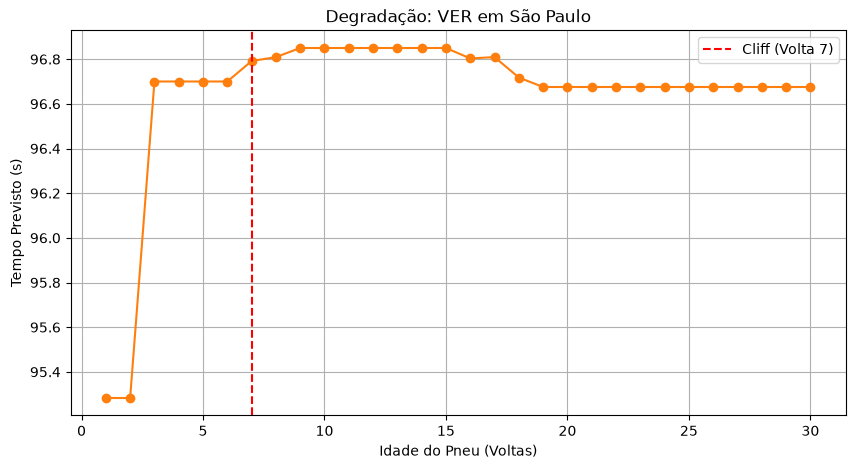

In [7]:
pista_simulacao = 'São Paulo'
piloto_simulacao = 'VER'

df_pista, volta_cliff, perda_tempo = simular_estrategia_otimizada(
    modelo = modelo_lote, 
    colunas_X = X_train.columns,  
    pista_alvo = pista_simulacao,
    piloto_alvo = piloto_simulacao,
    total_voltas = 30, 
    composto_ativo = 'Compound_SOFT'
)

print(f"\n=============================================")
print(f" RELATÓRIO: {piloto_simulacao} - {pista_simulacao} (Pneu Macio) ")
print(f"=============================================")
print(f"• Ponto de 'Cliff' detectado: Volta {volta_cliff}")
print(f"• Perda de ritmo estimada: +{perda_tempo:.3f}s")
print(f"• JANELA IDEAL DE PIT STOP: Voltas {volta_cliff - 1} a {volta_cliff}")
print(f"=============================================")

# Plotando o gráfico para validação visual
plt.figure(figsize=(10, 5))
plt.plot(df_pista['LapNumber'], df_pista['Tempo_Previsto'], marker='o', color='#ff7f0e')
plt.axvline(x=volta_cliff, color='red', linestyle='--', label=f'Cliff (Volta {volta_cliff})')
plt.title(f'Degradação: {piloto_simulacao} em {pista_simulacao}')
plt.xlabel('Idade do Pneu (Voltas)')
plt.ylabel('Tempo Previsto (s)')
plt.legend()
plt.grid(True)
plt.show()